# Bank Marketing Machine Learning Project

## Project Goal

A bank wants to identify customers who are more likely to subscribe to a term deposit.

This project uses customer and campaign information to build a Logistic Regression model that can estimate the likelihood of a customer saying **Yes**.

The goal is to help the bank focus its marketing efforts on customers with a higher predicted likelihood of subscribing.


# All Code used in this Project

I complied all the code i used for the purpose of a  quick overview. The code would not be ran in this section

In [269]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler, OneHotEncoder
#from sklearn.compose import ColumnTransformer
#from sklearn.pipeline import Pipeline
#from sklearn.linear_model import LogisticRegression
#from sklearn.metrics import ( accuracy_score, classification_report,confusion_matrix)

## 1. Load the Dataset

The dataset is the UCI Bank Marketing `bank-additional-full.csv` file. It uses a semicolon (`;`) as the separator.


In [270]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\user\Documents\bank-additional\bank-additional\bank-additional-full.csv", sep=";")

df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Initial Inspection

First, we inspect the size, structure, duplicates, and missing values in the dataset.


In [271]:
df.shape


(41188, 21)

In [272]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [273]:
df.duplicated().sum()


np.int64(12)

In [274]:
df.isnull().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [275]:
#This would keep both the original and the duplicated, for you to check if they are a direct match
df[df.duplicated(keep=False)]


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


## 3. Remove Exact Duplicates

There are 12 exact duplicate rows, so they are removed before modelling.


In [276]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())


Shape after removing duplicates: (41176, 21)
Duplicate rows remaining: 0


## 4. Check Recorded `unknown` Values

Some categorical variables contain `unknown`. These are recorded categories in the dataset rather than normal missing values.


In [277]:
df.eq("unknown").sum()


age                  0
job                330
marital             80
education         1730
default           8596
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [278]:
unknown_counts = (
    df.select_dtypes(include="str")
      .apply(lambda col: (col == "unknown").sum())
      .sort_values(ascending=False)
)

unknown_counts


default        8596
education      1730
housing         990
loan            990
job             330
marital          80
contact           0
month             0
day_of_week       0
poutcome          0
y                 0
dtype: int64

Default has the highest number of `unknown` values, while marital has the lowest. These observations are not automatically removed. Their relationship with the target variable should be assessed before making a decision.


### Relationship Between `default` and the Target

The percentages below are calculated within each `default` category. This helps us see how the outcome differs across the categories.


In [279]:
pd.crosstab(
    df["default"],
    df["y"],
    normalize="index"
) * 100


y,no,yes
default,,
no,87.119747,12.880253
unknown,94.846440,5.153560
yes,100.000000,0.000000


From the above, we can see that the default column matters for predicting who subscribes.
Customers with default = yes didn’t subscribe at all.
Customers with default = unknown also subscribed less than those with default = no.  Because the categories behave so differently, I would keep them in the data instead of deleting them. 

## 5. Check Special Values in `pdays`

The value `999` could be a  special code in `pdays`, so we inspect its frequency and then decide how to handle it.


In [280]:
df["pdays"].value_counts().head()


pdays
999    39661
3        439
6        412
4        118
9         64
Name: count, dtype: int64

From the above results, we can see that 999 is a special code, which means the customer was not previously contacted in the previous campaign. This makes us not to treat 999 as if it means 999 actual days.    We are still going to investigate further.


## 6. Summary Statistics

We review the numerical variables to understand their ranges and general values.


In [281]:
df.describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


looking at the above, no further changes are needed at this stage

## 7. Check the Target Distribution

The target variable `y` shows whether the customer subscribed to the term deposit. 

-`yes` = customer subscribed
-`no`= customer didnot subscribe


In [282]:
df["y"].value_counts(normalize=True) * 100


y
no     88.733728
yes    11.266272
Name: proportion, dtype: float64

Most customers in the data did not subscribe. 
 `No`: 88.73%  `Yes`: 11.27%  The data is  very much imbalanced. There are way more "No" than "Yes".
If a model just guessed "No" every time, it would still look 88% accurate and it  wouldn't be useful.So instead of only looking at accuracy, we’ll also check how well the model finds the customers who actually said "Yes".

## 8. Check Categories Before Modelling

We check the number of unique categories in each categorical column. This helps to identify strange categories or spelling differences that could lead to problems later.


In [283]:
pd.set_option('display.max_colwidth',None)

In [284]:
df.select_dtypes(include="str").nunique()


job            12
marital         4
education       8
default         3
housing         3
loan            3
contact         2
month          10
day_of_week     5
poutcome        3
y               2
dtype: int64

In [285]:
categorical_data = df.select_dtypes(
    include="str"
)

categorical_data.iloc[:, :6].apply(
    lambda col: col.unique()
)

job          [housemaid, services, admin., blue-collar, technician, retired, management, unemployed, self-employed, unknown, entrepreneur, student]
marital                                                                                                        [married, single, divorced, unknown]
education                                  [basic.4y, high.school, basic.6y, basic.9y, professional.course, unknown, university.degree, illiterate]
default                                                                                                                          [no, unknown, yes]
housing                                                                                                                          [no, yes, unknown]
loan                                                                                                                             [no, yes, unknown]
dtype: object

In [286]:
categorical_data.iloc[:, 6:].apply(
    lambda col: col.unique()
)

contact                                     [telephone, cellular]
month          [may, jun, jul, aug, oct, nov, dec, mar, apr, sep]
day_of_week                             [mon, tue, wed, thu, fri]
poutcome                          [nonexistent, failure, success]
y                                                       [no, yes]
dtype: object

From the above results, all the spellings are in check, and there are no consistencies

## 9. Investigate `pdays = 999`

When `pdays` is 999 but `previous` is greater than zero, we investigate these observations to check whether the  inconsistency is a data issue or has another explanation.


In [287]:
df.loc[
    (df["pdays"] == 999) &
    (df["previous"] > 0),
    ["pdays", "previous", "poutcome", "y"]
]


,pdays,previous,poutcome,y
24013,999,1,failure,no
24019,999,1,failure,yes
24076,999,1,failure,no
24102,999,1,failure,yes
24113,999,1,failure,no
...,...,...,...,...
41166,999,1,failure,yes
41170,999,4,failure,no
41173,999,2,failure,yes
41175,999,2,failure,no


We found above some customers where pdays = 999 but they actually had previous contacts. 

That doesn’t match what pdays is supposed to mean.  
But we don’t have proof of what the correct value should be.

So for now, we’ll keep the 999s as they are instead of guessing and changing them.

## 10. Column Guide

The main variables used in this project are:

| Column | Meaning |
|---|---|
| `age` | Customer's age |
| `job` | Type of job |
| `marital` | Marital status |
| `education` | Education level |
| `default` | Whether the customer has credit in default |
| `housing` | Whether the customer has a housing loan |
| `loan` | Whether the customer has a personal loan |
| `contact` | Type of contact used |
| `month` | Month of the campaign contact |
| `day_of_week` | Day of the week of the contact |
| `duration` | Duration of the current call, in seconds |
| `campaign` | Number of contacts during the current campaign |
| `pdays` | Days since the customer was last contacted in a previous campaign; `999` is a special value |
| `previous` | Number of contacts before the current campaign |
| `poutcome` | Outcome of the previous marketing campaign |
| `emp.var.rate` | Employment variation rate |
| `cons.price.idx` | Consumer price index |
| `cons.conf.idx` | Consumer confidence index |
| `euribor3m` | 3-month Euribor interest rate |
| `nr.employed` | Number of employees |
| `y` | Whether the customer subscribed to the term deposit |


## 11. Data Cleanup Preparation

We keep a copy of the cleaned dataset before making modelling changes.


In [288]:
df_clean = df.copy()


### Feature Selection

A variable can be valid and still be excluded if it gives the model information that would not be available when making the prediction.

`duration` is known only after the call, so it is excluded from the model.


In [289]:
df_clean["duration"].describe()


count    41176.000000
mean       258.315815
std        259.305321
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

In [290]:
df_clean = df_clean.drop(columns="duration")


### Convert the Target

The target contains only `yes` and `no`, so we convert it directly to 1 and 0 using `map`.


In [291]:
df_clean["y"] = df_clean["y"].map({
    "yes": 1,
    "no": 0
})


## 12. Separate Predictors and Target

The predictors contain the information used to make the prediction, while `y` is the outcome we want to predict.


In [292]:
X = df_clean.drop(columns="y")
y = df_clean["y"]


### Identify Categorical Columns

Categorical variables has labels rather than numerical measurements.


In [293]:
categorical_cols = X.select_dtypes(
    include="str"
).columns

categorical_cols


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')

### Convert Categorical Variables to Numerical Columns

Logistic Regression needs numerical input, so categorical variables are converted into 0/1  columns.


In [294]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X.shape


(41176, 52)

## 13. Train/Test Split

We keep 20% of the data for testing. `random_state=42` makes the split reproducible, while `stratify=y` keeps the same target proportions in both sets.


In [295]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (32940, 52)
X_test: (8236, 52)
y_train: (32940,)
y_test: (8236,)


## 14. Scale the Numerical Features

Scaling puts numerical features on a comparable scale so variables with larger values do not dominate the model.


In [296]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## 15. Check Correlations

We check the encoded predictor variables for strong relationships between predictors. Strong correlations can indicate possible multicollinearity.


In [297]:
X_original = pd.get_dummies(
    df_clean.drop(columns="y"),
    columns=df_clean.drop(columns="y").select_dtypes(
        include="str"
    ).columns,
    drop_first=True,
    dtype=int
)

X_original.corr()


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
age,1.000000,0.004622,-0.034381,0.024379,-0.000242,0.001009,0.129075,0.010852,-0.017607,-0.024178,...,-0.067496,0.030071,0.052506,0.040900,0.019035,-0.021347,0.019070,-0.023664,-0.016389,0.035638
campaign,0.004622,1.000000,0.052606,-0.079182,0.150786,0.127826,-0.013657,0.135169,0.144129,-0.001798,...,-0.032780,-0.079059,-0.049070,-0.033966,0.014401,0.005215,-0.025066,-0.021141,0.087691,-0.050914
pdays,-0.034381,0.052606,1.000000,-0.587508,0.271063,0.078920,-0.091374,0.296946,0.372659,0.065360,...,0.070718,-0.016946,-0.128795,-0.154624,0.001037,-0.008218,-0.007321,0.001049,0.491344,-0.950700
previous,0.024379,-0.079182,-0.587508,1.000000,-0.420587,-0.203197,-0.050929,-0.454571,-0.501411,-0.054885,...,-0.012572,0.081056,0.127895,0.157642,-0.002022,0.001564,0.000125,-0.003979,-0.878771,0.524038
emp.var.rate,-0.000242,0.150786,0.271063,-0.420587,1.000000,0.775293,0.196257,0.972244,0.906949,0.057229,...,-0.111377,-0.105949,-0.213486,-0.170402,-0.018257,-0.007764,0.014741,0.026791,0.472613,-0.256942
cons.price.idx,0.001009,0.127826,0.078920,-0.203197,0.775293,1.000000,0.059170,0.688180,0.521945,0.075246,...,-0.057333,-0.215310,-0.091896,-0.046924,0.001203,-0.017234,0.001397,0.012434,0.304354,-0.077446
cons.conf.idx,0.129075,-0.013657,-0.091374,-0.050929,0.196257,0.059170,1.000000,0.277864,0.100679,-0.101618,...,-0.011685,-0.052865,0.170042,0.169219,-0.041396,-0.027917,0.049952,0.023745,0.099725,0.084853
euribor3m,0.010852,0.135169,0.296946,-0.454571,0.972244,0.688180,0.277864,1.000000,0.945146,0.046743,...,-0.133863,0.019504,-0.185785,-0.190350,-0.023379,-0.013857,0.022852,0.030206,0.488492,-0.281066
nr.employed,-0.017607,0.144129,0.372659,-0.501411,0.906949,0.521945,0.100679,0.945146,1.000000,0.063924,...,-0.171784,0.027573,-0.273078,-0.292198,-0.017532,-0.002748,0.010042,0.023284,0.493130,-0.350663
job_blue-collar,-0.024178,-0.001798,0.065360,-0.054885,0.057229,0.075246,-0.101618,0.046743,0.063924,1.000000,...,0.136199,-0.062054,-0.048985,-0.054325,-0.009742,-0.007097,-0.006748,0.020626,0.043887,-0.061426


Some of the predictor variables were indeed highly correlated, especially the economic ones. 

This means they have similar information and because of that, the Logistic Regression coefficients are harder to interpret on their own.

I didn’t drop any of them  or carry out feature enginnering because the goal here was prediction, not explaining each coefficient.  

But if you want to interpret the coefficients, keep in mind that multicollinearity could be affecting them. 

## 16. Final Missing-Value Check

Before building the model, we make sure there are no missing values in the encoded predictor data.


In [298]:
X_original.isnull().sum()


age                              0
campaign                         0
pdays                            0
previous                         0
emp.var.rate                     0
cons.price.idx                   0
cons.conf.idx                    0
euribor3m                        0
nr.employed                      0
job_blue-collar                  0
job_entrepreneur                 0
job_housemaid                    0
job_management                   0
job_retired                      0
job_self-employed                0
job_services                     0
job_student                      0
job_technician                   0
job_unemployed                   0
job_unknown                      0
marital_married                  0
marital_single                   0
marital_unknown                  0
education_basic.6y               0
education_basic.9y               0
education_high.school            0
education_illiterate             0
education_professional.course    0
education_university

In [299]:
X_original.isnull().sum().sum()


np.int64(0)

# Model Building & Evaluation

We are now done with data preparation and can build the classification model.


## 17. Logistic Regression

Logistic Regression is suitable because the target has two possible outcomes: 1 (`Yes`) and 0 (`No`).


In [300]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## 18. Make Predictions

We use the trained model to make predictions on the test data that was kept separate from training.


In [301]:
y_pred = model.predict(X_test)


## 19. Model Accuracy

We compare the model's predictions with the actual test values.


In [302]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.898251578436134


Our model above got 89.83% accuracy.  
That means it was right about 90 times out of 100.

But most customers didn’t subscribe. So accuracy can be misleading.  
We’ll also check the confusion matrix and classification report to see how well it finds customers who actually subscribed.

## 20. Confusion Matrix

A confusion matrix shows how many predictions were correct and where the model made mistakes.


In [303]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm


array([[7204,  104],
       [ 734,  194]])

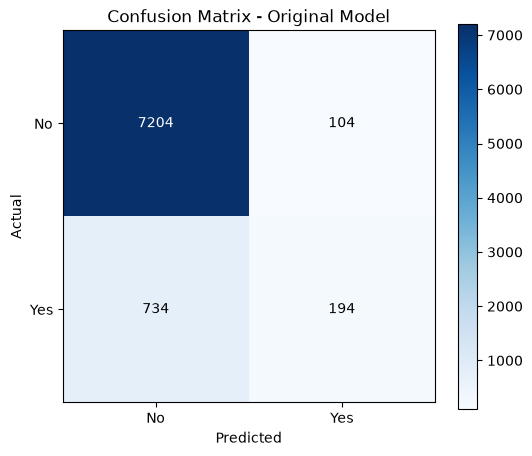

In [304]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm, cmap="Blues")
labels = ["No", "Yes"]

ax.set_xticks(range(2))
ax.set_xticklabels(labels)
ax.set_yticks(range(2))
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - Original Model")

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.colorbar(im)
plt.show()


The model got 7,204 non-subscribers right and 196 subscribers right.  
It was wrong 104 times by predicting "Yes" for non-subscribers.  
And it missed 734 actual subscribers by predicting "No".

Because it missed so many subscribers, accuracy alone isn’t enough.

## 21. Classification Report

Precision, recall and F1-score give a clearer picture of performance than accuracy alone, especially because the target classes are imbalanced.


In [305]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7308
           1       0.65      0.21      0.32       928

    accuracy                           0.90      8236
   macro avg       0.78      0.60      0.63      8236
weighted avg       0.88      0.90      0.87      8236



This report above shows how the model did for each group.

   Precision: When it predicted "Yes" or "No", how often was it right?
   Recall: Of all the actual "Yes" or "No" customers, how many did it find?
   F1-score: A balance of precision and recall.

The model was great at finding non-subscribers with 99% recall.  
But it was bad at finding subscribers with only 21% recall.

So even with high accuracy, it missed most of the people who actually subscribed.

## 22. Lazy Baseline

Before judging the model, we compare it with a simple baseline that predicts `No` for every customer. This shows whether the machine-learning model is better than doing nothing


In [306]:
lazy = np.zeros(len(y_test), dtype=int)

lazy_accuracy = accuracy_score(y_test, lazy)

print("Lazy baseline accuracy:", lazy_accuracy)


Lazy baseline accuracy: 0.8873239436619719


In [307]:
print(
    classification_report(
        y_test,
        lazy,
        zero_division=0
    )
)


              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7308
           1       0.00      0.00      0.00       928

    accuracy                           0.89      8236
   macro avg       0.44      0.50      0.47      8236
weighted avg       0.79      0.89      0.83      8236



The baseline gets high accuracy because most customers are in the `No` group, but it completely fails to identify the `Yes` group. This means our logistic model is better at predicting who actually subscribed. But it didnt do to well in identifying them. Thats why we have a low recall at 21%. Because of this, we have to train another regression to compare.


## 23. Balanced Logistic Regression

The “No” customers were much more than the “Yes” customers, so the first model paid more attention to the “No” group. We used class balancing to give the smaller “Yes” group a fairer chance to be identified.


In [308]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)

model_balanced.fit(X_train, y_train)


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strengt

In [309]:
y_pred_balanced = model_balanced.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_balanced,
        zero_division=0
    )
)


              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7308
           1       0.36      0.65      0.46       928

    accuracy                           0.83      8236
   macro avg       0.65      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236






<u>Balanced Model Results</u>

After using class balancing:Recall for "Yes": Went up from 21% to 65%. 

The model now finds 65 out of 100 actual subscribers. Precision for "Yes": Dropped from 65% to 36%. 

This means it also predicted more non-subscribers as subscibers by mistake.

The trade-off is that the model finds more subscribers, but makes more wrong "Yes" predictions too.
F1-score for "Yes": Improved from 32% to 46%.  

Overall, class balancing helped the model pay more attention to subscribers.The balanced model identifies more customers who actually subscribe, but it also predicts `Yes` more often. This increases the number of customers who are contacted unnecessarily.


## 24. Balanced Model Confusion Matrix


In [310]:
cm_balanced = confusion_matrix(
    y_test,
    y_pred_balanced
)

cm_balanced


array([[6238, 1070],
       [ 329,  599]])

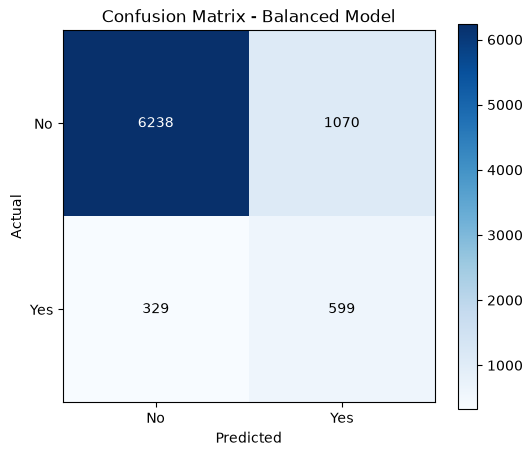

In [311]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm_balanced, cmap="Blues")
labels = ["No", "Yes"]

ax.set_xticks(range(2))
ax.set_xticklabels(labels)
ax.set_yticks(range(2))
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - Balanced Model")

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm_balanced[i, j],
            ha="center",
            va="center",
            color="white"
            if cm_balanced[i, j] > cm_balanced.max() / 2
            else "black"
        )

plt.colorbar(im)
plt.show()


## 25. Compare the Models

The comparison shows the trade-off between the baseline, the original model and the balanced model.


In [312]:
results = {
    "Lazy Baseline": {
        "Accuracy": accuracy_score(y_test, lazy),
        "Yes Precision": classification_report(
            y_test, lazy, output_dict=True, zero_division=0
        )["1"]["precision"],
        "Yes Recall": classification_report(
            y_test, lazy, output_dict=True, zero_division=0
        )["1"]["recall"],
        "Yes F1": classification_report(
            y_test, lazy, output_dict=True, zero_division=0
        )["1"]["f1-score"]
    },
    "Original Logistic": {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Yes Precision": classification_report(
            y_test, y_pred, output_dict=True, zero_division=0
        )["1"]["precision"],
        "Yes Recall": classification_report(
            y_test, y_pred, output_dict=True, zero_division=0
        )["1"]["recall"],
        "Yes F1": classification_report(
            y_test, y_pred, output_dict=True, zero_division=0
        )["1"]["f1-score"]
    },
    "Balanced Logistic": {
        "Accuracy": accuracy_score(y_test, y_pred_balanced),
        "Yes Precision": classification_report(
            y_test, y_pred_balanced, output_dict=True, zero_division=0
        )["1"]["precision"],
        "Yes Recall": classification_report(
            y_test, y_pred_balanced, output_dict=True, zero_division=0
        )["1"]["recall"],
        "Yes F1": classification_report(
            y_test, y_pred_balanced, output_dict=True, zero_division=0
        )["1"]["f1-score"]
    }
}

pd.DataFrame(results).round(3)


,Lazy Baseline,Original Logistic,Balanced Logistic
Accuracy,0.887,0.898,0.830
Yes Precision,0.000,0.651,0.359
Yes Recall,0.000,0.209,0.645
Yes F1,0.000,0.316,0.461


## 26. Customer-Level Predictions

The model's predictions can be connected back to the original customers using the test-set index.


In [313]:
customer_results = df_clean.loc[y_test.index].copy()

customer_results["Predicted"] = np.where(
    y_pred_balanced == 1,
    "Yes",
    "No"
)

customer_results["Probability"] = (
    model_balanced.predict_proba(X_test)[:, 1] * 100
).round(1)

customer_results[[
    "age",
    "job",
    "marital",
    "education",
    "housing",
    "loan",
    "Predicted",
    "Probability"
]].head(10)


,age,job,marital,education,housing,loan,Predicted,Probability
8490,35,services,married,high.school,no,no,No,18.6
40844,30,student,single,professional.course,yes,no,Yes,95.8
35681,37,self-employed,single,basic.4y,yes,no,No,30.7
35994,31,blue-collar,single,professional.course,no,no,No,45.0
21961,31,technician,married,university.degree,unknown,unknown,No,33.7
11522,52,blue-collar,married,basic.9y,no,no,No,26.4
35058,48,blue-collar,married,basic.9y,no,no,No,44.8
31093,46,admin.,married,high.school,yes,no,No,33.7
32880,35,services,divorced,university.degree,yes,no,No,41.4
22655,58,technician,divorced,professional.course,no,no,No,25.1


The probability shows how likely the model considers a `Yes` outcome. This can help the bank prioritize customers rather than treating every customer equally.


## 27. Model Coefficients

Coefficients tells us which features makes a subscription more or less likely. 


In [314]:
coefficients = pd.DataFrame({
    "Feature": X_original.columns,
    "Coefficient": model_balanced.coef_[0]
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
).head(10)


,Feature,Coefficient
5,cons.price.idx,1.125816
7,euribor3m,0.404747
8,nr.employed,0.399187
37,month_aug,0.242297
41,month_mar,0.173085
51,poutcome_success,0.123291
50,poutcome_nonexistent,0.117761
6,cons.conf.idx,0.099149
21,marital_single,0.078024
13,job_retired,0.071952


In [315]:
coefficients.sort_values(
    by="Coefficient",
    ascending=True
).head(10)


,Feature,Coefficient
4,emp.var.rate,-2.258506
36,contact_telephone,-0.312376
2,pdays,-0.236767
40,month_jun,-0.194162
42,month_may,-0.194070
1,campaign,-0.113204
43,month_nov,-0.102563
30,default_unknown,-0.074017
3,previous,-0.071705
46,day_of_week_mon,-0.054945


<u>Interpreting Coefficients above</u> 

   Positive coefficient: Increases the chance of a customer subscribing to "Yes".  
   Negative coefficient: Decreases the chance of a customer subscribing to "Yes".

But be careful because they don’t really prove what causes someone to subscribe.

And also because some features are related to each other, we should interpret each coefficient carefully.

# Final Model Pipeline

The final pipeline combines preprocessing and Logistic Regression into one model. This makes it easier to apply the same preprocessing to future customer data.


In [316]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

categorical_cols = df_clean.drop(
    columns="y"
).select_dtypes(
    include="str"
).columns

numerical_cols = df_clean.drop(
    columns="y"
).select_dtypes(
    exclude="str"
).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ), categorical_cols)
    ]
)


In [317]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

X_train_raw = df_clean.drop(
    columns="y"
).loc[y_train.index]

X_test_raw = df_clean.drop(
    columns="y"
).loc[y_test.index]

final_model.fit(
    X_train_raw,
    y_train
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all re

In [318]:
y_pred_final = final_model.predict(X_test_raw)

print(
    classification_report(
        y_test,
        y_pred_final,
        zero_division=0
    )
)


              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7308
           1       0.36      0.65      0.46       928

    accuracy                           0.83      8236
   macro avg       0.65      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236



The final pipeline produces performance very close to the balanced model because it performs the same main preprocessing and modelling steps automatically.


## Using the Final Model on New Customer Data




In [319]:
"""A future customer file can be passed into the pipeline in its original format. The pipeline handles the encoding and scaling before making predictions.


new_data = pd.read_csv("new_customers.csv")

predictions = final_model.predict(new_data)

probabilities = (
    final_model.predict_proba(new_data)[:, 1] * 100
).round(1)


The new data should contain the predictor columns used by the model and should not contain the target column `y`. """


'A future customer file can be passed into the pipeline in its original format. The pipeline handles the encoding and scaling before making predictions.\n\n\nnew_data = pd.read_csv("new_customers.csv")\n\npredictions = final_model.predict(new_data)\n\nprobabilities = (\n    final_model.predict_proba(new_data)[:, 1] * 100\n).round(1)\n\n\nThe new data should contain the predictor columns used by the model and should not contain the target column `y`. '

# Business Insights & Conclusion

## Business Problem

A bank wants to identify customers who are more likely to subscribe to a term deposit after a marketing campaign.

The goal is to use customer and campaign information to predict which customers are more likely to say `Yes`, so the bank can focus its marketing efforts on customers with higher predicted likelihood.


## Key Findings

- The dataset is imbalanced, with most customers not subscribing.
- The original Logistic Regression model achieved high accuracy but had low recall for customers who subscribed.
- Class balancing improved recall for the `Yes` class from about 21% to about 65%.
- The balanced model identifies more potential subscribers, although it produces more false-positive predictions.
- The model can generate customer-level predictions and estimated probabilities.


## Business Implications

The model can help the bank prioritize customers who are more likely to subscribe to a term deposit. Instead of contacting all customers equally, the bank could use predicted probabilities to focus marketing efforts on higher-likelihood customers.

The balanced model is particularly useful when the bank wants to identify more potential subscribers. However, the bank must also consider the cost of contacting customers who ultimately do not subscribe.


## Limitations

- The model is trained on historical data, so future performance may differ.
- The balanced model improves the ability to find subscribers but reduces precision for the `Yes` class.
- Correlation and model coefficients do not prove that a variable causes subscription.
- `duration` was excluded because it is only known after the call and would not be available for a realistic pre-call prediction.
- The model should support business decisions rather than automatically make decisions without human judgement.


## Conclusion

This project demonstrates how customer and campaign data can be used to build a classification model for bank marketing.

The balanced Logistic Regression model is useful when the business wants to identify more potential subscribers, while recognizing the additional marketing effort that may come from incorrect `Yes` predictions.

The final pipeline packages the preprocessing and model together, making the project easier to apply to future customer data.
